# 📊 Net Migration Explorer (NME) — Travis County, Texas
**Data Source:** [netmigration.wisc.edu](https://netmigration.wisc.edu/)  
**Dataset:** NME_1020 (Net Migration Estimates 2010–2020)  
**Focus:** Travis County, Texas (FIPS: 48453)

---
### Variable Code Key
Variables follow the pattern: `[period][race][sex][age]`
- **Period prefix:** `f1` = Population 2020, `m1` = Net Migrants 2010s, `e1` = Expected Pop 2020, `r1` = Net Migration Rate
- **Race:** `an` = Asian/Pacific Islander, `bn` = Black non-Hispanic, `th` = Hispanic, `it` = American Indian/Alaska Native, `wn` = White non-Hispanic, `tt` = Total
- **Sex:** `f` = Female, `m` = Male, `t` = Total
- **Age:** `0`, `5`, `10`, ... `85` = 5-year age groups (0=0–4, 5=5–9, etc.)

## 🔧 Step 1: Install & Import Libraries

In [19]:
# Install any missing libraries (uncomment if needed in Colab)
# !pip install plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 📁 Step 2: Upload & Load Data
Upload the ZIP file you downloaded from netmigration.wisc.edu — or upload the extracted CSVs directly.

In [20]:
# ── Option A: Upload the ZIP and extract it ──────────────────────────────────
from google.colab import files
import zipfile, io, os

print('📂 Please upload your NME_1020_data.zip file...')
uploaded = files.upload()   # A dialog will pop up — select NME_1020_data.zip

for fname, content in uploaded.items():
    if fname.endswith('.zip'):
        with zipfile.ZipFile(io.BytesIO(content)) as z:
            z.extractall('.')
        print(f'✅ Extracted: {z.namelist()}')
    else:
        with open(fname, 'wb') as f:
            f.write(content)
        print(f'✅ Saved: {fname}')

# ── Option B: If files are already extracted, just run from here ──────────────
# (Skip the upload block above and set paths manually)
DATA_FILE = 'NME_1020_data.csv'
DICT_FILE = 'NME_1020_datadict.csv'

📂 Please upload your NME_1020_data.zip file...


Saving NME_1020_data.zip to NME_1020_data (1).zip
✅ Extracted: ['NME_1020_DataSupressionNote.docx', 'NME_1020_data.csv', 'NME_1020_datadict.csv']


## 🔍 Step 3: Load & Filter for Travis County, Texas

In [21]:
# Load full dataset
print('Loading dataset (this may take a moment for ~17MB file)...')
df_full = pd.read_csv(DATA_FILE, low_memory=False)
print(f'✅ Full dataset: {df_full.shape[0]:,} rows × {df_full.shape[1]:,} columns')

# Load data dictionary
dd = pd.read_csv(DICT_FILE)
var_labels = dict(zip(dd['name'], dd['varlab']))
print(f'✅ Data dictionary: {len(var_labels):,} variable labels loaded')

Loading dataset (this may take a moment for ~17MB file)...
✅ Full dataset: 3,190 rows × 1,372 columns
✅ Data dictionary: 1,372 variable labels loaded


In [22]:
# Filter for Travis County, Texas
travis = df_full[
    (df_full['STNAME'] == 'Texas') &
    (df_full['CoName2020'] == 'Travis County')
].copy()

print(f'✅ Travis County rows found: {len(travis)}')
print(f'   FIPS Code: {travis["fips_str2020"].values[0]}')
travis[['STNAME', 'CoName2020', 'fips_str2020']].head()

✅ Travis County rows found: 1
   FIPS Code: 48453


,STNAME,CoName2020,fips_str2020
2790,Texas,Travis County,48453


## 🧹 Step 4: Parse & Reshape the Data
The dataset uses a compact wide format. We'll build a helper to reshape it into tidy long-format DataFrames for analysis.

In [23]:
# ── Helper: parse a variable code into its components ──────────────────────
RACE_MAP = {
    'an': 'Asian/Pacific Islander',
    'bn': 'Black non-Hispanic',
    'th': 'Hispanic',
    'it': 'Am. Indian/Alaska Native',
    'wn': 'White non-Hispanic',
    'tt': 'Total'
}
SEX_MAP  = {'f': 'Female', 'm': 'Male', 't': 'Total'}
PERIOD_MAP = {
    'f1': 'Population 2020',
    'm1': 'Net Migrants 2010s',
    'e1': 'Expected Pop 2020',
    'r1': 'Net Migration Rate'
}

def parse_col(col):
    """Parse variable code like 'm1bnm30' → dict of period/race/sex/age."""
    if len(col) < 5:
        return None
    period = col[:2]
    race   = col[2:4]
    sex    = col[4]
    age_s  = col[5:]
    if period not in PERIOD_MAP or race not in RACE_MAP or sex not in SEX_MAP:
        return None
    # 't' suffix codes are totals across age, numeric are 5-yr groups
    try:
        age = int(age_s)
    except ValueError:
        age = 'Total'
    return {
        'col': col,
        'period': PERIOD_MAP[period],
        'race': RACE_MAP[race],
        'sex': SEX_MAP[sex],
        'age': age
    }

# Build a metadata dataframe for all parsed columns
meta_rows = [parse_col(c) for c in df_full.columns if parse_col(c)]
meta = pd.DataFrame(meta_rows)
print(f'✅ Parsed {len(meta):,} data columns')
print(f"   Periods: {meta['period'].unique().tolist()}")
print(f"   Races:   {meta['race'].unique().tolist()}")
meta.head()

✅ Parsed 1,368 data columns
   Periods: ['Population 2020', 'Net Migrants 2010s', 'Expected Pop 2020', 'Net Migration Rate']
   Races:   ['Asian/Pacific Islander', 'Black non-Hispanic', 'Hispanic', 'Am. Indian/Alaska Native', 'White non-Hispanic', 'Total']


,col,period,race,sex,age
0,f1anf0,Population 2020,Asian/Pacific Islander,Female,0
1,f1anf5,Population 2020,Asian/Pacific Islander,Female,5
2,f1anf10,Population 2020,Asian/Pacific Islander,Female,10
3,f1anf15,Population 2020,Asian/Pacific Islander,Female,15
4,f1anf20,Population 2020,Asian/Pacific Islander,Female,20


In [24]:
# ── Build a tidy long-format DataFrame for Travis County ──────────────────
def make_long(county_row, period_label, age_only=True):
    """Melt a county row for a specific period into long format."""
    subset = meta[(meta['period'] == period_label)]
    if age_only:
        subset = subset[subset['age'] != 'Total']
    cols = subset['col'].tolist()
    vals = county_row[cols].values.flatten().astype(float)
    result = subset[['race','sex','age']].copy().reset_index(drop=True)
    result['value'] = vals
    return result

row = travis.iloc[0]

pop_long      = make_long(row, 'Population 2020')
mig_long      = make_long(row, 'Net Migrants 2010s')
rate_long     = make_long(row, 'Net Migration Rate')
exp_long      = make_long(row, 'Expected Pop 2020')

print('Population 2020 shape:', pop_long.shape)
print('Net Migrants shape:   ', mig_long.shape)
mig_long.head(10)

Population 2020 shape: (324, 4)
Net Migrants shape:    (324, 4)


,race,sex,age,value
0,Asian/Pacific Islander,Female,0,-400.0
1,Asian/Pacific Islander,Female,5,48.0
2,Asian/Pacific Islander,Female,10,301.0
3,Asian/Pacific Islander,Female,15,1055.0
4,Asian/Pacific Islander,Female,20,1800.0
5,Asian/Pacific Islander,Female,25,3302.0
6,Asian/Pacific Islander,Female,30,2097.0
7,Asian/Pacific Islander,Female,35,1364.0
8,Asian/Pacific Islander,Female,40,1003.0
9,Asian/Pacific Islander,Female,45,752.0


## 📊 Step 5: Exploratory Data Analysis (EDA)
### 5.1 — Total Population by Race/Ethnicity (2020)

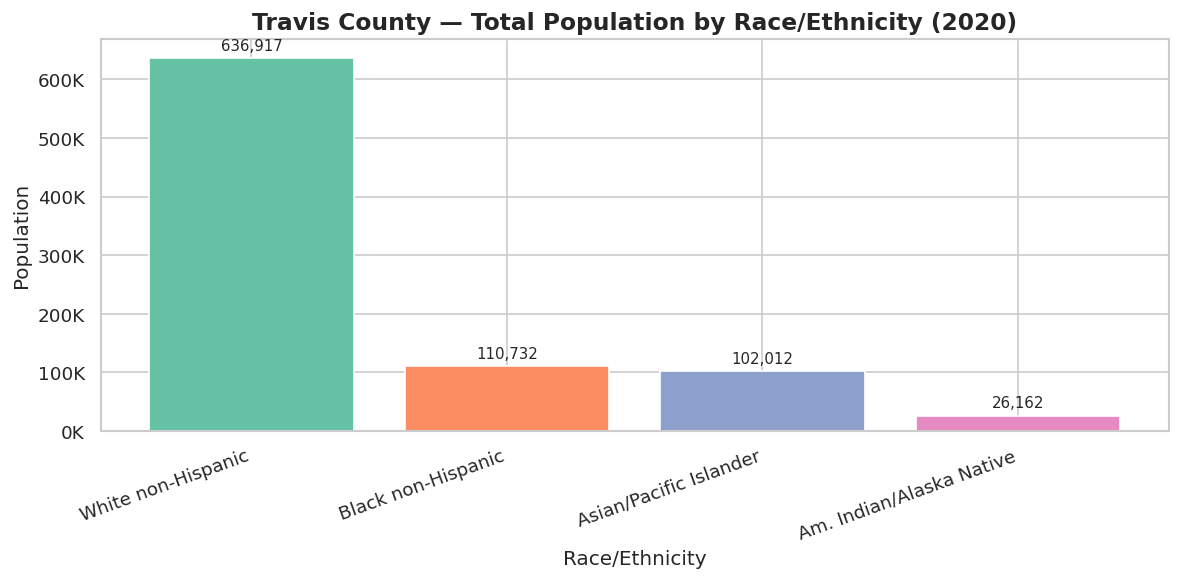

White non-Hispanic          636917.38
Black non-Hispanic          110731.90
Asian/Pacific Islander      102011.70
Am. Indian/Alaska Native     26162.00


In [25]:
# Total population per race (all ages, both sexes, from totals)
pop_total_meta = meta[
    (meta['period'] == 'Population 2020') &
    (meta['sex'] == 'Total') &
    (meta['age'] == 'Total') &
    (meta['race'] != 'Total')
]

pop_by_race = {}
for _, r in pop_total_meta.iterrows():
    val = pd.to_numeric(row[r['col']], errors='coerce')
    if not pd.isna(val):
        pop_by_race[r['race']] = val

pop_race_df = pd.Series(pop_by_race).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('Set2', len(pop_race_df))
bars = ax.bar(pop_race_df.index, pop_race_df.values, color=colors)
ax.bar_label(bars, fmt=lambda x: f'{x:,.0f}', padding=3, fontsize=9)
ax.set_title('Travis County — Total Population by Race/Ethnicity (2020)', fontsize=14, fontweight='bold')
ax.set_ylabel('Population')
ax.set_xlabel('Race/Ethnicity')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('travis_pop_by_race.png', bbox_inches='tight')
plt.show()
print(pop_race_df.to_string())

### 5.2 — Age Pyramid: Population Structure by Sex (2020)

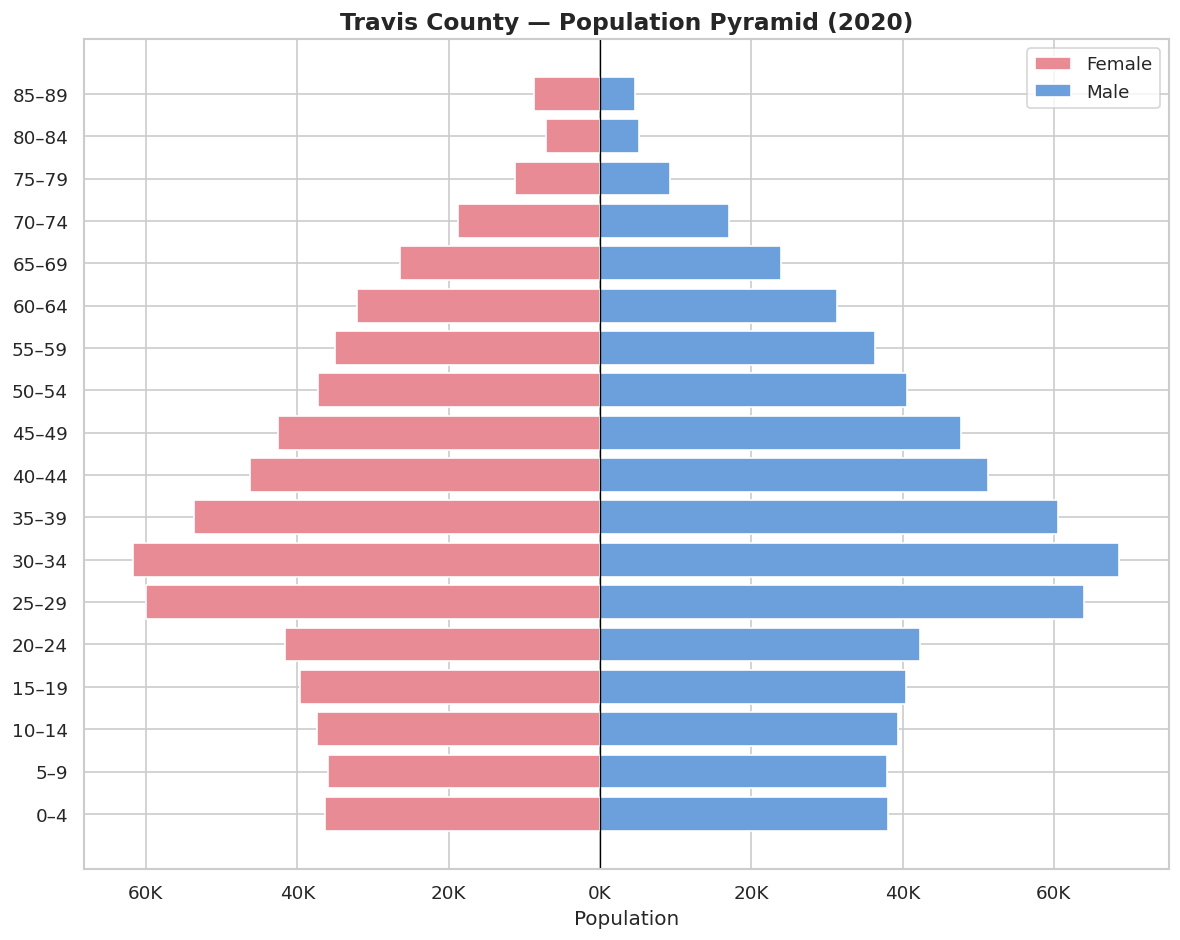

In [26]:
# Population pyramid (all races combined = 'Total' race)
pyr = pop_long[(pop_long['race'] == 'Total') & (pop_long['sex'] != 'Total') & (pop_long['age'] != 'Total')].copy()
pyr = pyr.dropna(subset=['value'])
ages = sorted(pyr['age'].unique())
age_labels = [f'{a}–{a+4}' for a in ages]

female = pyr[pyr['sex']=='Female'].sort_values('age')['value'].values
male   = pyr[pyr['sex']=='Male'].sort_values('age')['value'].values

fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(ages))
ax.barh(y, -female, color='#E88B94', label='Female')
ax.barh(y,  male,   color='#6CA0DC', label='Male')
ax.set_yticks(y)
ax.set_yticklabels(age_labels)
ax.set_xlabel('Population')
ax.set_title('Travis County — Population Pyramid (2020)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{abs(x)/1000:.0f}K'))
ax.axvline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig('travis_age_pyramid.png', bbox_inches='tight')
plt.show()

### 5.3 — Net Migrants 2010s: Who Moved In/Out?

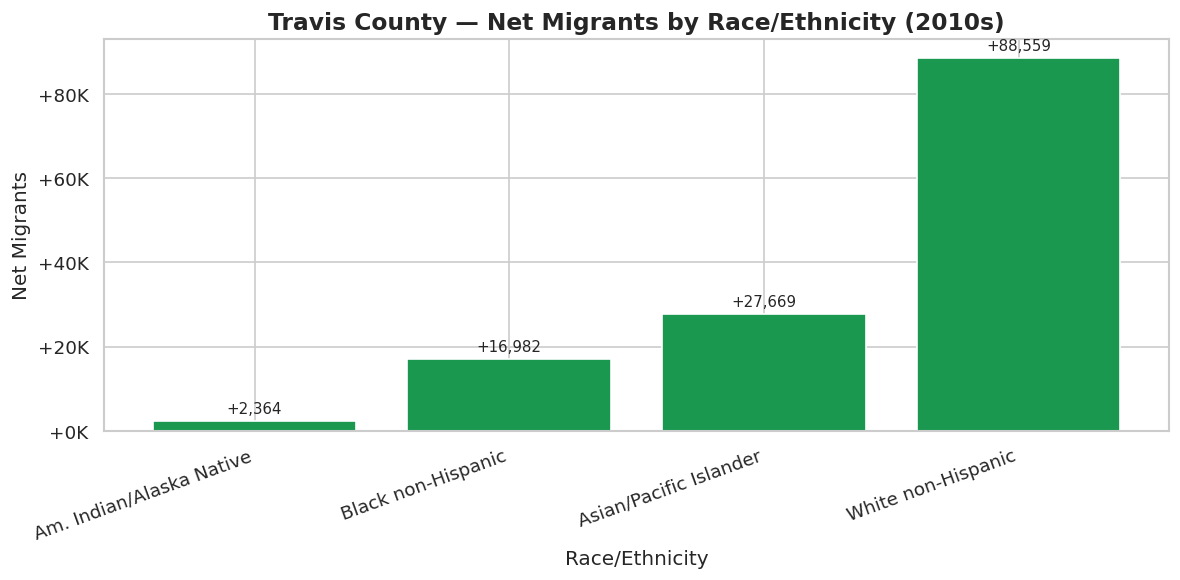

Net Migrants by Race:
Am. Indian/Alaska Native     2364
Black non-Hispanic          16982
Asian/Pacific Islander      27669
White non-Hispanic          88559


In [27]:
# Net migrants by race, total across all ages
mig_total_meta = meta[
    (meta['period'] == 'Net Migrants 2010s') &
    (meta['sex'] == 'Total') &
    (meta['age'] == 'Total') &
    (meta['race'] != 'Total')
]

mig_by_race = {}
for _, r in mig_total_meta.iterrows():
    val = pd.to_numeric(row[r['col']], errors='coerce')
    if not pd.isna(val):
        mig_by_race[r['race']] = val

mig_race_df = pd.Series(mig_by_race).sort_values()

colors = ['#d73027' if v < 0 else '#1a9850' for v in mig_race_df.values]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(mig_race_df.index, mig_race_df.values, color=colors)
ax.bar_label(bars, fmt=lambda x: f'{x:+,.0f}', padding=3, fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Travis County — Net Migrants by Race/Ethnicity (2010s)', fontsize=14, fontweight='bold')
ax.set_ylabel('Net Migrants')
ax.set_xlabel('Race/Ethnicity')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:+.0f}K'))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('travis_net_migrants_race.png', bbox_inches='tight')
plt.show()
print('Net Migrants by Race:')
print(mig_race_df.to_string())

### 5.4 — Net Migration by Age Group (All Races)

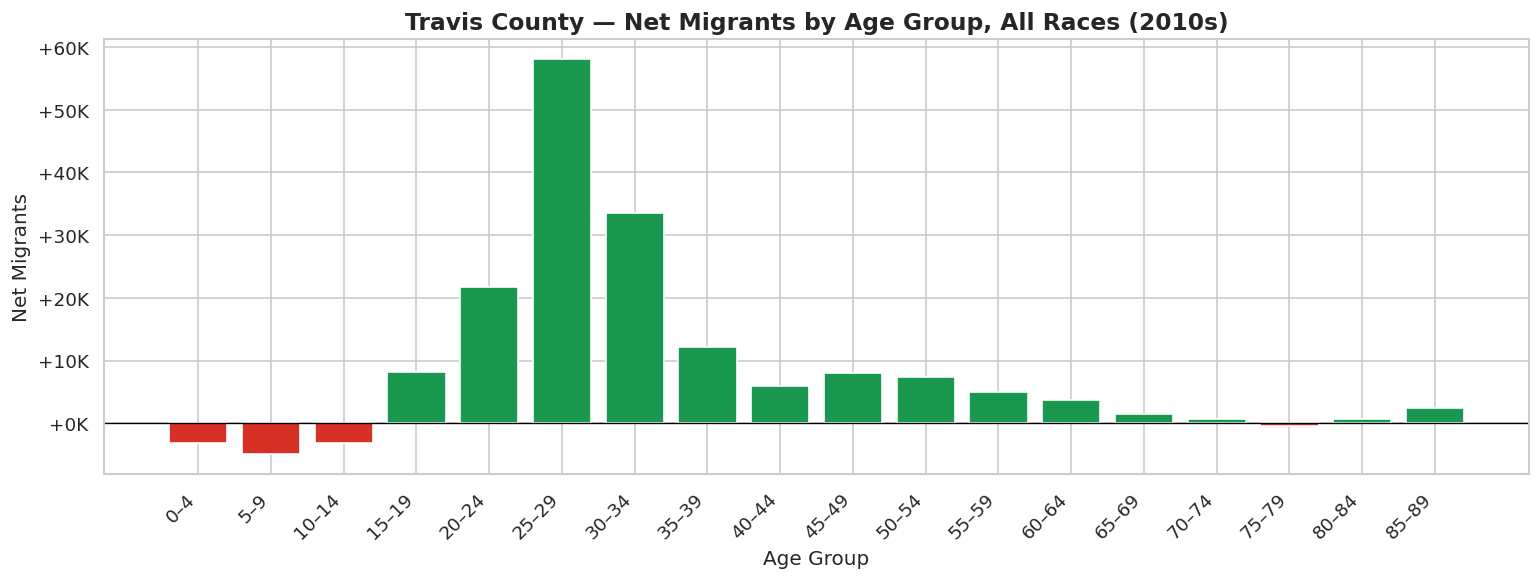

In [28]:
mig_age = mig_long[
    (mig_long['race'] == 'Total') &
    (mig_long['sex'] == 'Total') &
    (mig_long['age'] != 'Total')
].dropna(subset=['value']).sort_values('age')

age_labels = [f'{int(a)}–{int(a)+4}' for a in mig_age['age']]
colors = ['#d73027' if v < 0 else '#1a9850' for v in mig_age['value']]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(age_labels, mig_age['value'].values, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Travis County — Net Migrants by Age Group, All Races (2010s)', fontsize=14, fontweight='bold')
ax.set_ylabel('Net Migrants')
ax.set_xlabel('Age Group')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:+.0f}K'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('travis_net_migrants_age.png', bbox_inches='tight')
plt.show()

### 5.5 — Net Migration Rate Heatmap: Race × Age

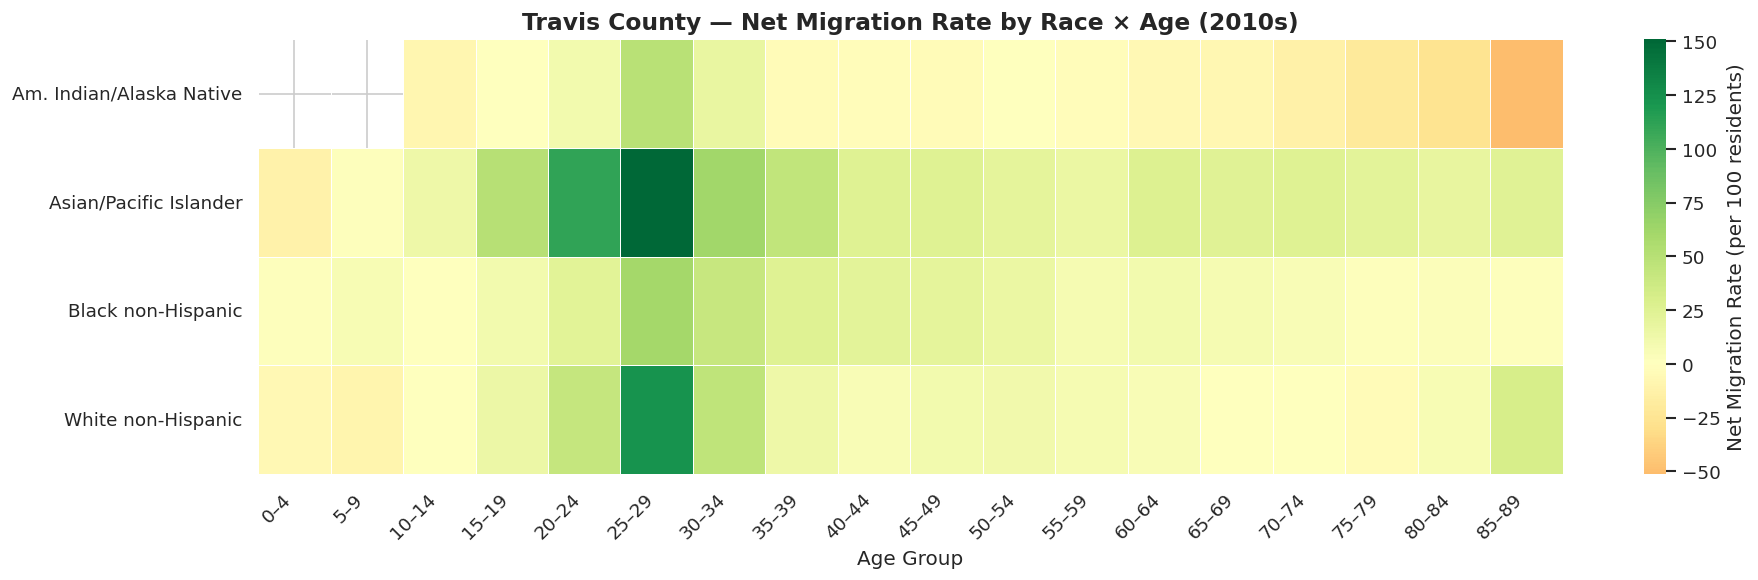

In [29]:
rate_heat = rate_long[
    (rate_long['sex'] == 'Total') &
    (rate_long['race'] != 'Total') &
    (rate_long['age'] != 'Total')
].dropna(subset=['value']).copy()

pivot = rate_heat.pivot_table(index='race', columns='age', values='value')
pivot.columns = [f'{int(c)}–{int(c)+4}' for c in pivot.columns]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot, annot=False, fmt='.0f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    cbar_kws={'label': 'Net Migration Rate (per 100 residents)'},
    ax=ax
)
ax.set_title('Travis County — Net Migration Rate by Race × Age (2010s)', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('travis_rate_heatmap.png', bbox_inches='tight')
plt.show()

### 5.6 — Interactive Plot: Age-Specific Migration Rate by Race

In [30]:
rate_plot = rate_long[
    (rate_long['sex'] == 'Total') &
    (rate_long['race'] != 'Total') &
    (rate_long['age'] != 'Total')
].dropna(subset=['value']).copy()

rate_plot['age_label'] = rate_plot['age'].apply(lambda a: f'{int(a)}–{int(a)+4}')

fig = px.line(
    rate_plot.sort_values('age'),
    x='age', y='value', color='race',
    markers=True,
    title='Travis County — Net Migration Rate by Age & Race (2010s)',
    labels={'age': 'Age Group Start', 'value': 'Net Migration Rate', 'race': 'Race/Ethnicity'},
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.add_hline(y=0, line_dash='dash', line_color='gray')
fig.update_layout(hovermode='x unified', height=480)
fig.show()

### 5.7 — Observed vs Expected Population: Did Travis Over- or Under-Attract?

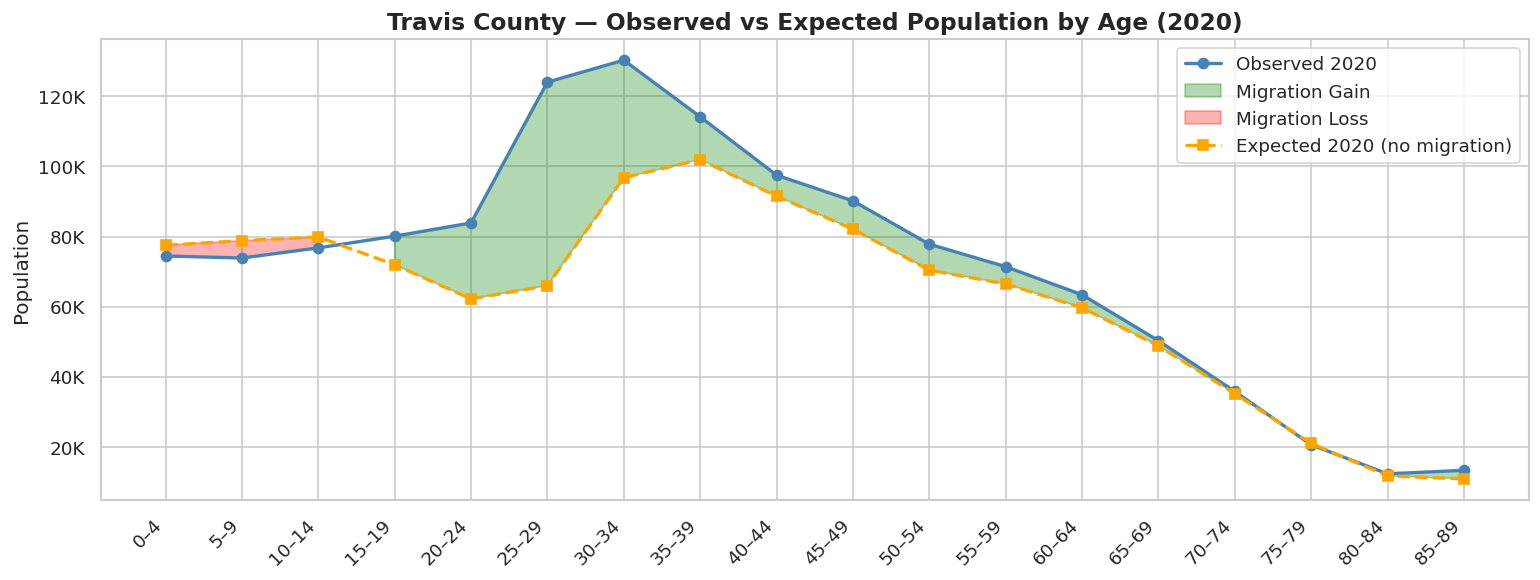

In [31]:
# Compare observed 2020 pop vs expected 2020 pop (= 2010 pop + nat. growth, no migration)
obs_meta = meta[(meta['period'] == 'Population 2020')  & (meta['sex']=='Total') & (meta['age'] != 'Total') & (meta['race'] == 'Total')]
exp_meta = meta[(meta['period'] == 'Expected Pop 2020') & (meta['sex']=='Total') & (meta['age'] != 'Total') & (meta['race'] == 'Total')]

obs_vals = row[obs_meta.sort_values('age')['col'].values].astype(float).values
exp_vals = row[exp_meta.sort_values('age')['col'].values].astype(float).values
ages_num = sorted(obs_meta['age'].unique())
age_lbs  = [f'{int(a)}–{int(a)+4}' for a in ages_num]

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(age_lbs))
ax.plot(x, obs_vals, 'o-', color='steelblue', label='Observed 2020', linewidth=2)
ax.fill_between(x, exp_vals, obs_vals,
                where=obs_vals > exp_vals, alpha=0.3, color='green', label='Migration Gain')
ax.fill_between(x, exp_vals, obs_vals,
                where=obs_vals < exp_vals, alpha=0.3, color='red',   label='Migration Loss')
ax.plot(x, exp_vals, 's--', color='orange', label='Expected 2020 (no migration)', linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(age_lbs, rotation=45, ha='right')
ax.set_title('Travis County — Observed vs Expected Population by Age (2020)', fontsize=14, fontweight='bold')
ax.set_ylabel('Population')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig('travis_obs_vs_exp.png', bbox_inches='tight')
plt.show()

### 5.8 — Gender Gap in Migration

In [32]:
mig_gender = mig_long[
    (mig_long['race'] == 'Total') &
    (mig_long['sex'] != 'Total') &
    (mig_long['age'] != 'Total')
].dropna(subset=['value']).sort_values('age').copy()

fig = px.bar(
    mig_gender,
    x='age', y='value', color='sex', barmode='group',
    title='Travis County — Net Migrants by Age & Gender (2010s)',
    labels={'age': 'Age Group Start', 'value': 'Net Migrants', 'sex': 'Gender'},
    color_discrete_map={'Female': '#E88B94', 'Male': '#6CA0DC'}
)
fig.add_hline(y=0, line_dash='dash', line_color='gray')
fig.update_layout(height=460)
fig.show()

## 📈 Step 6: Summary Statistics

In [33]:
# ── Grand Summary Table ───────────────────────────────────────────────────
# Total population, total net migrants, and net migration rate by race
summary_rows = []
for race_code, race_label in RACE_MAP.items():
    if race_label == 'Total':
        continue
    pop_col  = f'f1{race_code}tt'   # total pop
    mig_col  = f'm1{race_code}tt'   # total net migrants
    rate_col = f'r1{race_code}tt'   # net migration rate
    summary_rows.append({
        'Race/Ethnicity'      : race_label,
        'Population 2020'     : pd.to_numeric(row.get(pop_col,  np.nan), errors='coerce'),
        'Net Migrants 2010s'  : pd.to_numeric(row.get(mig_col,  np.nan), errors='coerce'),
        'Net Migration Rate'  : pd.to_numeric(row.get(rate_col, np.nan), errors='coerce'),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Race/Ethnicity')

# Format for display
styled = summary_df.style \
    .format({'Population 2020': '{:,.0f}',
             'Net Migrants 2010s': '{:+,.0f}',
             'Net Migration Rate': '{:+.2f}%'}) \
    .background_gradient(subset=['Net Migrants 2010s'], cmap='RdYlGn') \
    .background_gradient(subset=['Net Migration Rate'], cmap='RdYlGn') \
    .set_caption('Travis County, TX — Migration Summary by Race/Ethnicity (2010–2020)')

styled

,Population 2020,Net Migrants 2010s,Net Migration Rate
Race/Ethnicity,,,
Asian/Pacific Islander,"102,012","+27,669",+37.22%
Black non-Hispanic,"110,732","+16,982",+18.11%
Hispanic,nan,+nan,+nan%
Am. Indian/Alaska Native,"26,162","+2,364",+9.93%
White non-Hispanic,"636,917","+88,559",+16.15%


## 🔑 Step 7: Key Findings & Recommendations

Run the cell below to print automated insights derived from your data.

In [34]:
print('=' * 65)
print('  TRAVIS COUNTY, TX — NET MIGRATION KEY FINDINGS (2010–2020)')
print('=' * 65)

# Total net migrants
total_mig = pd.to_numeric(row.get('m1tttt', np.nan), errors='coerce')
total_pop = pd.to_numeric(row.get('f1tttt', np.nan), errors='coerce')
total_rate = pd.to_numeric(row.get('r1tttt', np.nan), errors='coerce')

if not pd.isna(total_mig):
    print(f'\n📌 Total Net Migrants (2010s): {total_mig:+,.0f}')
    print(f'📌 Total Population (2020):    {total_pop:,.0f}')
    print(f'📌 Overall Net Migration Rate: {total_rate:+.2f}%')

print('\n--- By Race/Ethnicity ---')
for _, r_row in summary_df.iterrows():
    if not pd.isna(r_row['Net Migrants 2010s']):
        direction = '📈 GAINED' if r_row['Net Migrants 2010s'] > 0 else '📉 LOST'
        print(f"  {r_row.name:<30} {direction} {r_row['Net Migrants 2010s']:>+10,.0f} (rate: {r_row['Net Migration Rate']:+.1f}%)")

print('\n--- Highest Net In-migration Age Group (All Races) ---')
top_age = mig_long[
    (mig_long['race']=='Total') & (mig_long['sex']=='Total') & (mig_long['age']!='Total')
].dropna().sort_values('value', ascending=False).head(3)
for _, tr in top_age.iterrows():
    print(f"  Ages {int(tr['age'])}–{int(tr['age'])+4}: {tr['value']:+,.0f} net migrants")

print('\n--- Highest Net Out-migration Age Group (All Races) ---')
bot_age = mig_long[
    (mig_long['race']=='Total') & (mig_long['sex']=='Total') & (mig_long['age']!='Total')
].dropna().sort_values('value').head(3)
for _, tr in bot_age.iterrows():
    print(f"  Ages {int(tr['age'])}–{int(tr['age'])+4}: {tr['value']:+,.0f} net migrants")

print('\n' + '=' * 65)

  TRAVIS COUNTY, TX — NET MIGRATION KEY FINDINGS (2010–2020)

📌 Total Net Migrants (2010s): +157,559
📌 Total Population (2020):    1,290,209
📌 Overall Net Migration Rate: +13.91%

--- By Race/Ethnicity ---
  Asian/Pacific Islander         📈 GAINED    +27,669 (rate: +37.2%)
  Black non-Hispanic             📈 GAINED    +16,982 (rate: +18.1%)
  Am. Indian/Alaska Native       📈 GAINED     +2,364 (rate: +9.9%)
  White non-Hispanic             📈 GAINED    +88,559 (rate: +16.1%)

--- Highest Net In-migration Age Group (All Races) ---
  Ages 25–29: +58,100 net migrants
  Ages 30–34: +33,564 net migrants
  Ages 20–24: +21,685 net migrants

--- Highest Net Out-migration Age Group (All Races) ---
  Ages 5–9: -4,955 net migrants
  Ages 10–14: -3,107 net migrants
  Ages 0–4: -3,058 net migrants



## 💾 Step 8: Export Results

In [38]:
# Export a tidy CSV of all Travis County values (long format)
all_long = []
for period_label in PERIOD_MAP.values():
    tmp = make_long(row, period_label, age_only=False)
    tmp.insert(0, 'period', period_label)
    all_long.append(tmp)

travis_long = pd.concat(all_long, ignore_index=True)
travis_long.to_csv('travis_county_nme_tidy.csv', index=False)
summary_df.reset_index().to_csv('travis_county_summary.csv', index=False)

print('✅ Exported:')
print('   → travis_county_nme_tidy.csv   (all metrics, long format)')
print('   → travis_county_summary.csv    (summary by race)')

# Download from Colab
from google.colab import files
files.download('travis_county_nme_tidy.csv')
files.download('travis_county_summary.csv')

✅ Exported:
   → travis_county_nme_tidy.csv   (all metrics, long format)
   → travis_county_summary.csv    (summary by race)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 📌 Recommendations for Further Analysis

| # | Direction | What to do |
|---|-----------|------------|
| 1 | **Compare with Texas Statewide** | Filter for `CoName2020 == 'State Total'` in Texas rows and compare Travis County rates |
| 2 | **Peer County Comparison** | Compare Travis with Harris (Houston), Bexar (San Antonio), Dallas counties |
| 3 | **Age-Race Interaction** | Facet the heatmap by sex to detect gendered migration patterns by race |
| 4 | **Suppressed Values** | Some cells are `NaN` due to data suppression (small counts). Check the suppression note docx. |
| 5 | **Correlation Analysis** | Compute `np.corrcoef(pop_2020, net_migrants)` to check if larger groups have larger migration |
| 6 | **Choropleth Map** | Use the FIPS code + `plotly.express.choropleth` to map migration rates across Texas counties |

---
*Generated for the NME 2010–2020 dataset, Travis County, Texas.*